# Run model-segres-10.pt on 1 image
CPU is fine — single 2048x2048 image tiled into 512x512 tiles, resnet34 encoder, no GPU needed.

In [ ]:
import json
import os
import numpy as np
import torch
import torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
from pycocotools import mask as mask_utils
from scipy import ndimage
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

In [17]:
CHECKPOINT_PATH = "data/model-segres-25.pt"
TRAIN_IMAGES_DIR = "/home/kumail/.cache/kagglehub/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026/train/train_images"
ANNOTATIONS_PATH = "/home/kumail/.cache/kagglehub/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026/train/MAGFiLO_1.0_Annotations_kaggle2026_train.json"
IMAGE_FILE = "20110918112834Ch.jpeg"
IMAGE_PATH = os.path.join(TRAIN_IMAGES_DIR, IMAGE_FILE)

TILE_SIZE = 512
OVERLAP = 64
IMAGE_HEIGHT = 2048
IMAGE_WIDTH = 2048
PRED_THRESHOLD = 0.9
MIN_AREA = 1000  

GRAYSCALE_MEAN = (0.449,)
GRAYSCALE_STD = (0.226,)

## Tiling helpers (same as training notebook)

In [18]:
def _axis_coordinates(size, tile_size, stride):
    if size <= tile_size:
        return [0]
    n_tiles = int(np.ceil((size - tile_size) / stride)) + 1
    positions = np.linspace(0, size - tile_size, n_tiles)
    return sorted({int(round(p)) for p in positions})


def get_tile_coordinates(height, width, tile_size=512, overlap=64):
    stride = tile_size - overlap
    ys = _axis_coordinates(height, tile_size, stride)
    xs = _axis_coordinates(width, tile_size, stride)
    return [(y, x) for y in ys for x in xs]


def extract_tile(array, y, x, tile_size=512):
    tile = array[y:y + tile_size, x:x + tile_size]
    return np.ascontiguousarray(tile)


def stitch_predictions(pred_tiles, coords, height, width, tile_size=512):
    full_pred = np.zeros((height, width), dtype=np.float32)
    count_map = np.zeros((height, width), dtype=np.float32)
    for pred_tile, (y, x) in zip(pred_tiles, coords):
        full_pred[y:y + tile_size, x:x + tile_size] += pred_tile
        count_map[y:y + tile_size, x:x + tile_size] += 1.0
    count_map[count_map == 0] = 1.0
    return full_pred / count_map

In [19]:
def label_and_filter(binary_mask, min_area=1):
    """Label connected components and drop specks smaller than min_area (same as predict-kaggle.ipynb)."""
    labeled, num_features = ndimage.label(binary_mask)
    if num_features == 0:
        return np.zeros_like(binary_mask, dtype=np.uint8), []

    areas = np.bincount(labeled.ravel(), minlength=num_features + 1)
    keep_ids = np.nonzero(areas[1:] >= min_area)[0] + 1

    cleaned = np.isin(labeled, keep_ids).astype(np.uint8)
    instances = [(labeled == label_id).astype(np.uint8) for label_id in keep_ids]

    return cleaned, instances

## Ground-truth mask decode (same as training notebook)

In [20]:
DEFAULT_CATEGORY_IDS = frozenset({1, 2, 3})  # 1=Left, 2=Right, 3=Unidentifiable; all mark a filament


def load_annotations(json_path):
    with open(json_path, "r") as f:
        return json.load(f)


def build_lookup_tables(data):
    images_by_id = {img["id"]: img for img in data["images"]}
    anns_by_image_id = {}
    for ann in data["annotations"]:
        anns_by_image_id.setdefault(ann["image_id"], []).append(ann)
    return images_by_id, anns_by_image_id


def build_file_to_annotations(data):
    images_by_id, anns_by_image_id = build_lookup_tables(data)
    file_to_anns = {}
    for image_id, image_info in sorted(images_by_id.items()):
        file_name = image_info["file_name"]
        file_to_anns.setdefault(file_name, []).extend(anns_by_image_id.get(image_id, []))
    return file_to_anns


def polygon_to_mask(segmentation, height, width):
    rle = mask_utils.frPyObjects(segmentation, height, width)
    if isinstance(rle, list):
        rle = mask_utils.merge(rle)
    return mask_utils.decode(rle)


def build_combined_mask(annotations, height, width, category_ids=DEFAULT_CATEGORY_IDS):
    combined = np.zeros((height, width), dtype=np.uint8)
    for ann in annotations:
        if category_ids is not None and ann["category_id"] not in category_ids:
            continue
        m = polygon_to_mask(ann["segmentation"], height, width)
        combined = np.logical_or(combined, m).astype(np.uint8)
    return combined

## Load model

In [21]:
def build_model(encoder_weights=None):
    return smp.UnetPlusPlus(
        encoder_name="resnet34",
        encoder_weights=encoder_weights,
        in_channels=1,
        classes=1,
    )

model = build_model(encoder_weights=None)
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
# checkpoint is {"model", "optimizer", "scheduler", "best_dice"}, not a bare state_dict
model.load_state_dict(ckpt["model"])
model.to(device)
model.eval()
print("loaded, best_dice at save time:", ckpt["best_dice"])

loaded, best_dice at save time: 0.38133164744928993


## Run on 1 image

In [22]:
transform = A.Compose([
    A.Normalize(mean=GRAYSCALE_MEAN, std=GRAYSCALE_STD),
    ToTensorV2(),
])

image = np.array(Image.open(IMAGE_PATH).convert("L"))
coords = get_tile_coordinates(IMAGE_HEIGHT, IMAGE_WIDTH, TILE_SIZE, OVERLAP)

pred_tiles = []
with torch.no_grad():
    for (y, x) in coords:
        tile = extract_tile(image, y, x, TILE_SIZE)
        tile_t = transform(image=tile)["image"].unsqueeze(0).to(device)
        logits = model(tile_t)
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred_tiles.append(prob)

stitched = stitch_predictions(pred_tiles, coords, IMAGE_HEIGHT, IMAGE_WIDTH, TILE_SIZE)
raw_binary_mask = (stitched > PRED_THRESHOLD).astype(np.uint8)
binary_mask, instances = label_and_filter(raw_binary_mask, min_area=MIN_AREA)
print("predicted filament pixels (raw):", raw_binary_mask.sum(), "/", raw_binary_mask.size)
print("predicted filament pixels (min_area filtered):", binary_mask.sum(), "/", binary_mask.size, f"({len(instances)} instances)")

KeyboardInterrupt: 

In [ ]:
ann_data = load_annotations(ANNOTATIONS_PATH)
file_to_anns = build_file_to_annotations(ann_data)
gt_mask = build_combined_mask(file_to_anns.get(IMAGE_FILE, []), IMAGE_HEIGHT, IMAGE_WIDTH)
print("ground-truth filament pixels:", gt_mask.sum(), "/", gt_mask.size)

ground-truth filament pixels: 28515 / 4194304


## Show it: input, real, predicted

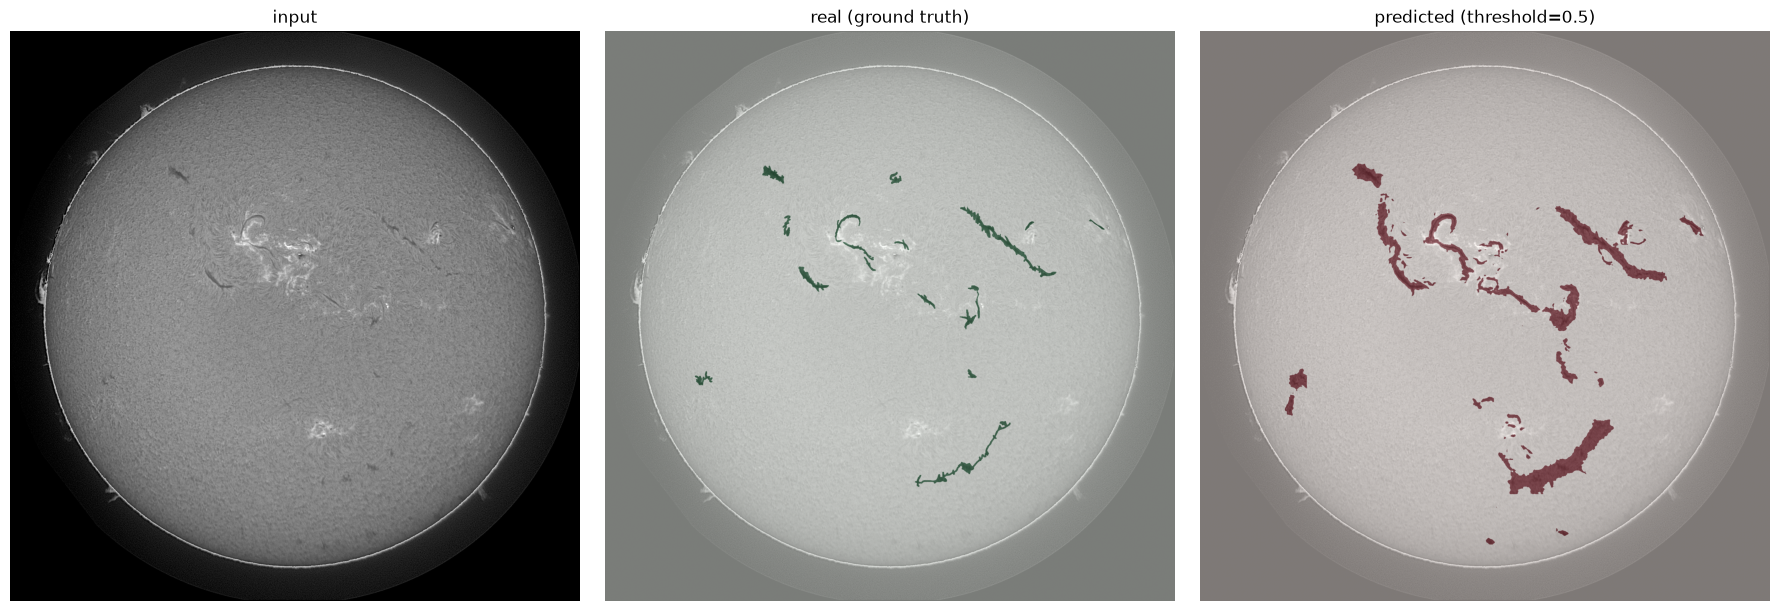

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("input")

axes[1].imshow(image, cmap="gray")
axes[1].imshow(gt_mask, cmap="Greens", alpha=0.5)
axes[1].set_title("real (ground truth)")

axes[2].imshow(image, cmap="gray")
axes[2].imshow(binary_mask, cmap="Reds", alpha=0.5)
axes[2].set_title(f"predicted (threshold={PRED_THRESHOLD})")

# name 
fil_name_viz = IMAGE_FILE.split('.')[0]


for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig(f'visuals/{fil_name_viz}_25epoch_{PRED_THRESHOLD}_{MIN_AREA}.png', dpi=300)
plt.show()